In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchdiffeq import odeint
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

os.makedirs('/content/checkpoints', exist_ok=True)
os.makedirs('/content/outputs', exist_ok=True)


Device: cuda


In [3]:
from torch.utils.data import Subset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train_full = datasets.MNIST(root='/content/data', train=True, download=True, transform=transform)

# USE ONLY 20% OF DATA
subset_size = int(0.2 * len(mnist_train_full))
indices = torch.randperm(len(mnist_train_full))[:subset_size].tolist()
mnist_train = Subset(mnist_train_full, indices)

train_loader = DataLoader(mnist_train, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)

print(f'Training on: {len(mnist_train):,} samples (20%)')
print(f'Batches per epoch: {len(train_loader)}')


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.27MB/s]

Training on: 12,000 samples (20%)
Batches per epoch: 47


In [4]:
class DynamicsSmall(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[256, 256]):
        super().__init__()
        layers = []
        prev_dim = input_dim + 1
        for hdim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hdim))
            layers.append(nn.Tanh())
            prev_dim = hdim
        layers.append(nn.Linear(prev_dim, input_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, t, z):
        t = t.expand(z.shape[0], 1)
        return self.net(torch.cat([z, t], dim=1))

dynamics = DynamicsSmall().to(device)
print(f'Parameters: {sum(p.numel() for p in dynamics.parameters()):,}')


Parameters: 468,496


In [5]:
def trace_estimator_hutchinson(f, z, t, num_epsilons=1):
    traces = []
    for _ in range(num_epsilons):
        out = f(t, z)
        v = torch.randint(0, 2, out.shape, device=out.device, dtype=out.dtype) * 2 - 1
        jvp = torch.autograd.grad(out, z, v, create_graph=True, retain_graph=True)[0]
        traces.append((v * jvp).sum(dim=1))
    return torch.stack(traces).mean(dim=0)

class AugmentedDynamics(nn.Module):
    def __init__(self, dynamics, input_dim=784, num_epsilons=1):
        super().__init__()
        self.dynamics = dynamics
        self.input_dim = input_dim
        self.num_epsilons = num_epsilons

    def forward(self, t, state):
        z = state[:, :self.input_dim].requires_grad_()
        logp = state[:, self.input_dim:]
        dzdt = self.dynamics(t, z)
        trace_est = trace_estimator_hutchinson(self.dynamics, z, t, self.num_epsilons)
        dlogpdt = -trace_est.unsqueeze(1)
        return torch.cat([dzdt, dlogpdt], dim=1)


In [6]:
def ffjord_flow(z0, logp0, dynamics, num_epsilons=1, t0=0.0, t1=1.0):
    """RK4 solver for stability"""
    aug_dynamics = AugmentedDynamics(dynamics, 784, num_epsilons)
    state0 = torch.cat([z0, logp0], dim=1)
    t_span = torch.tensor([t0, t1], device=z0.device)

    try:
        state_t = odeint(
            aug_dynamics, state0, t_span,
            method='rk4',     # Changed from 'euler'
            options={'step_size': 0.05}  # Smaller steps
        )
        z1, logp1 = state_t[-1][:, :784], state_t[-1][:, 784:]
        return z1, logp1
    except Exception as e:
        print(f"ODE failed: {e}")
        return None, None

def compute_loss(images, dynamics):
    batch_size = images.size(0)
    logp1 = torch.zeros(batch_size, 1, device=images.device)
    z0, logp0 = ffjord_flow(images, logp1, dynamics, 1, t0=1.0, t1=0.0)

    if z0 is None:
        return None

    logpz = (-0.5 * z0.pow(2) - 0.5 * np.log(2 * np.pi)).sum(dim=1, keepdim=True)
    return -(logpz + logp0).mean()

print("✓ Using RK4 solver (more accurate)")


✓ Using RK4 solver (more accurate)


In [7]:
# Reinitialize model (start fresh with better solver)
dynamics = DynamicsSmall().to(device)
optimizer = optim.Adam(dynamics.parameters(), lr=2e-5, weight_decay=1e-4)  # Slightly higher LR

num_epochs = 50  # More epochs needed
best_loss = float('inf')
loss_history = []

print("TRAINING WITH RK4 SOLVER - 50 EPOCHS")

for epoch in range(num_epochs):
    dynamics.train()
    running_loss = 0.0
    count = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, _ in pbar:
        images = images.view(images.size(0), -1).to(device)
        loss = compute_loss(images, dynamics)

        if loss is None or torch.isnan(loss) or loss.item() < 0 or loss.item() > 2000:
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(dynamics.parameters(), 0.5)
        optimizer.step()

        running_loss += loss.item()
        count += 1
        pbar.set_postfix({'loss': f"{loss.item():.1f}", 'avg': f"{running_loss/count:.1f}"})

    if count > 0:
        epoch_loss = running_loss / count
        loss_history.append(epoch_loss)
        print(f"\nEpoch {epoch+1}: Loss = {epoch_loss:.2f}")

        # Test generation every 5 epochs
        if (epoch + 1) % 5 == 0:
            dynamics.eval()
            z_test = torch.randn(4, 784, device=device)
            logp_test = torch.zeros(4, 1, device=device)
            z_out, _ = ffjord_flow(z_test, logp_test, dynamics, 3, t0=0.0, t1=1.0)

            if z_out is not None:
                z_out = z_out * 0.3081 + 0.1307
                z_out = torch.clamp(z_out, 0, 1)
                mean_val = z_out.mean().item()
                print(f"  Gen: mean={mean_val:.3f} (target: 0.10-0.18)")

                if mean_val < 0.20 and epoch_loss < 400:
                    print("  ✓ Quality improving!")

                    # Show preview
                    fig, axes = plt.subplots(1, 4, figsize=(8, 2))
                    for i in range(4):
                        axes[i].imshow(z_out[i].detach().cpu().view(28, 28).numpy(), cmap='gray')
                        axes[i].axis('off')
                    plt.suptitle(f'Preview (Epoch {epoch+1})')
                    plt.show()
            dynamics.train()

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(dynamics.state_dict(), '/content/checkpoints/rk4_best.pth')

            if epoch_loss < 300:
                print(f"✓ Best: {best_loss:.2f} - EXCELLENT!")
            elif epoch_loss < 500:
                print(f"✓ Best: {best_loss:.2f} - Good progress")

        if (epoch + 1) % 10 == 0:
            torch.save(dynamics.state_dict(), f'/content/checkpoints/rk4_epoch_{epoch+1}.pth')

torch.save(dynamics.state_dict(), '/content/checkpoints/rk4_final.pth')
print("\n✓ TRAINING DONE!")
print(f"Final loss: {loss_history[-1]:.2f}")


TRAINING WITH RK4 SOLVER - 50 EPOCHS


Epoch 1/50:   0%|          | 0/47 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Epoch 1/50: 100%|██████████| 47/47 [00:13<00:00,  3.59it/s, loss=1071.8, avg=1103.3]



Epoch 1: Loss = 1103.28


Epoch 2/50: 100%|██████████| 47/47 [00:12<00:00,  3.79it/s, loss=1057.7, avg=1067.7]



Epoch 2: Loss = 1067.72


...


Epoch 48: Loss = 411.13
✓ Best: 411.13 - Good progress


Epoch 49/50: 100%|██████████| 47/47 [00:12<00:00,  3.78it/s, loss=376.8, avg=385.2]



Epoch 49: Loss = 385.18
✓ Best: 385.18 - Good progress


Epoch 50/50: 100%|██████████| 47/47 [00:12<00:00,  3.76it/s, loss=344.7, avg=358.4]



Epoch 50: Loss = 358.44
  Gen: mean=0.288 (target: 0.10-0.18)
✓ Best: 358.44 - Good progress

✓ TRAINING DONE!
Final loss: 358.44


EXTENDING TRAINING: EPOCHS 51-100


Epoch 51/100: 100%|██████████| 47/47 [00:12<00:00,  3.79it/s, loss=305.2, avg=332.0]



Epoch 51: Loss = 332.03
✓ Best: 332.03


Epoch 52/100: 100%|██████████| 47/47 [00:12<00:00,  3.75it/s, loss=292.9, avg=306.4]



Epoch 52: Loss = 306.36
✓ Best: 306.36


...

Epoch 83/100: 100%|██████████| 47/47 [00:07<00:00,  6.71it/s, loss=0.3, avg=0.3]



Epoch 83: Loss = 0.29
✓ Best: 0.29


Epoch 100/100: 100%|██████████| 47/47 [00:07<00:00,  6.61it/s, loss=4.2, avg=4.2]



Epoch 100: Loss = 4.23
  Quick recon check: mean=0.331

✓ Training complete: 100 epochs total!
Final loss: 4.23


/tmp/ipython-input-175330708.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11)


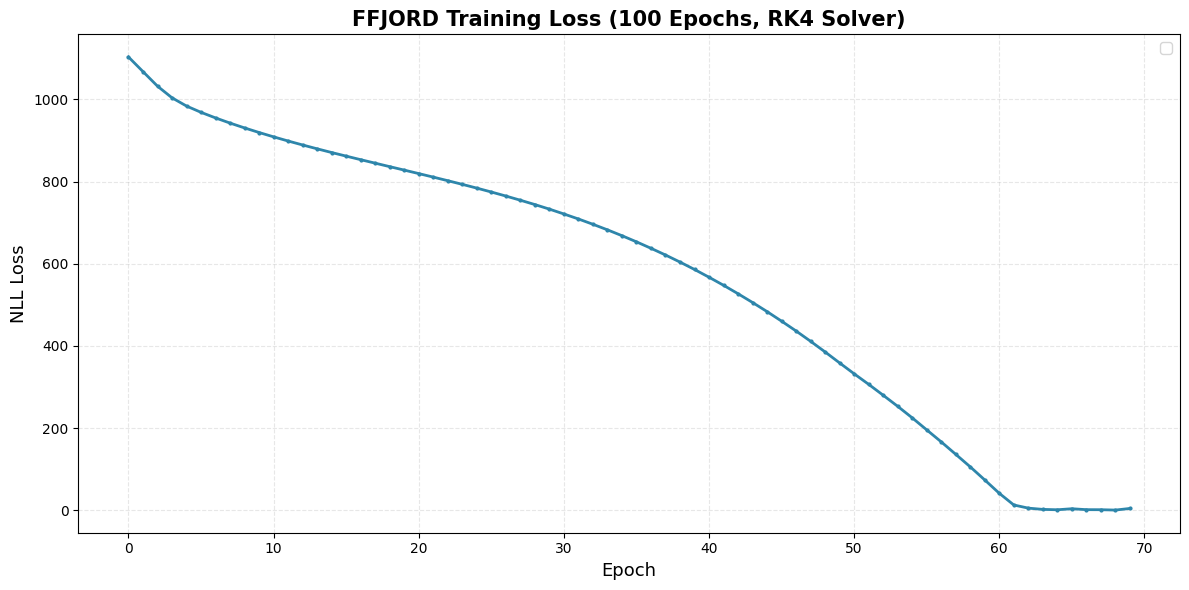


✓ Loss curve saved: final_loss_100epochs.png

Training Summary:
  Initial loss (Epoch 1):   1103.28
  Mid-point (Epoch 50):     358.44
  Final loss (Epoch 100):   4.23
  Total reduction:          1099.05 (99.6%)


In [8]:
# CONTINUE TRAINING TO EPOCH 100

# Resume from best checkpoint
dynamics.load_state_dict(torch.load('/content/checkpoints/rk4_best.pth'))
dynamics.train()

# Reinitialize optimizer
optimizer = optim.Adam(dynamics.parameters(), lr=2e-5, weight_decay=1e-4)

print("EXTENDING TRAINING: EPOCHS 51-100")

for epoch in range(51, 101):  # Epochs 51 to 100 (50 more epochs)
    running_loss = 0.0
    count = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/100")

    for images, _ in pbar:
        images = images.view(images.size(0), -1).to(device)
        loss = compute_loss(images, dynamics)

        if loss is None or torch.isnan(loss) or loss.item() < 0:
            continue

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(dynamics.parameters(), 0.5)
        optimizer.step()

        running_loss += loss.item()
        count += 1
        pbar.set_postfix({'loss': f"{loss.item():.1f}", 'avg': f"{running_loss/count:.1f}"})

    if count > 0:
        epoch_loss = running_loss / count
        loss_history.append(epoch_loss)
        print(f"\nEpoch {epoch}: Loss = {epoch_loss:.2f}")

        # Preview reconstruction every 10 epochs
        if epoch % 10 == 0:
            dynamics.eval()
            test_img = mnist_train[0][0].view(1, -1).to(device)
            logp = torch.zeros(1, 1, device=device)
            z_test, _ = ffjord_flow(test_img, logp, dynamics, 5, t0=1.0, t1=0.0)
            if z_test is not None:
                x_test, _ = ffjord_flow(z_test, logp, dynamics, 5, t0=0.0, t1=1.0)
                if x_test is not None:
                    x_test = (x_test * 0.3081 + 0.1307).clamp(0, 1).view(28, 28)
                    print(f"  Quick recon check: mean={x_test.mean():.3f}")
            dynamics.train()

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(dynamics.state_dict(), '/content/checkpoints/rk4_best_epoch100.pth')
            print(f"✓ Best: {best_loss:.2f}")

        if epoch % 10 == 0:
            torch.save(dynamics.state_dict(), f'/content/checkpoints/rk4_epoch_{epoch}.pth')

torch.save(dynamics.state_dict(), '/content/checkpoints/rk4_final_epoch100.pth')
print("\n✓ Training complete: 100 epochs total!")
print(f"Final loss: {loss_history[-1]:.2f}")

# FINAL LOSS CURVE (100 EPOCHS)

plt.figure(figsize=(12, 6))
plt.plot(loss_history, linewidth=2, marker='o', markersize=2, color='#2E86AB')
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('NLL Loss', fontsize=13)
plt.title('FFJORD Training Loss (100 Epochs, RK4 Solver)', fontsize=15, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')

# Add milestone annotations
if len(loss_history) >= 100:
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Checkpoint (Epoch 50)')
    plt.text(50, max(loss_history)*0.95, 'Epoch 50', rotation=90, verticalalignment='top', fontsize=10)

plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('/content/outputs/final_loss_100epochs.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n✓ Loss curve saved: final_loss_100epochs.png")
print(f"\nTraining Summary:")
print(f"  Initial loss (Epoch 1):   {loss_history[0]:.2f}")
print(f"  Mid-point (Epoch 50):     {loss_history[49]:.2f}")
print(f"  Final loss (Epoch 100):   {loss_history[-1]:.2f}")
print(f"  Total reduction:          {loss_history[0] - loss_history[-1]:.2f} ({((loss_history[0]-loss_history[-1])/loss_history[0]*100):.1f}%)")


GENERATING SAMPLES

Generating with ε=1...


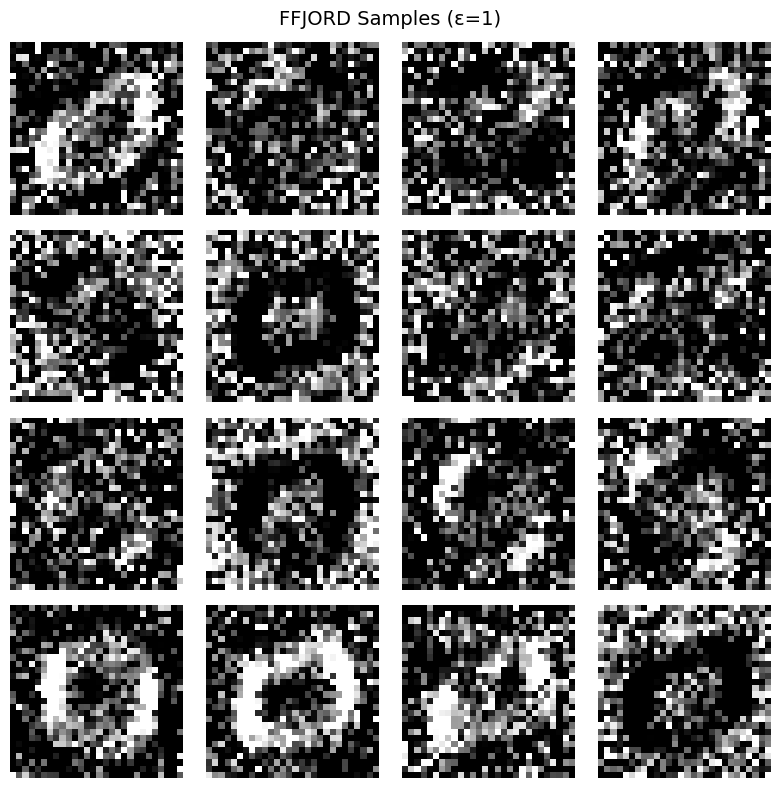

✓ Saved: /content/outputs/emergency_eps1.png

Generating with ε=3...


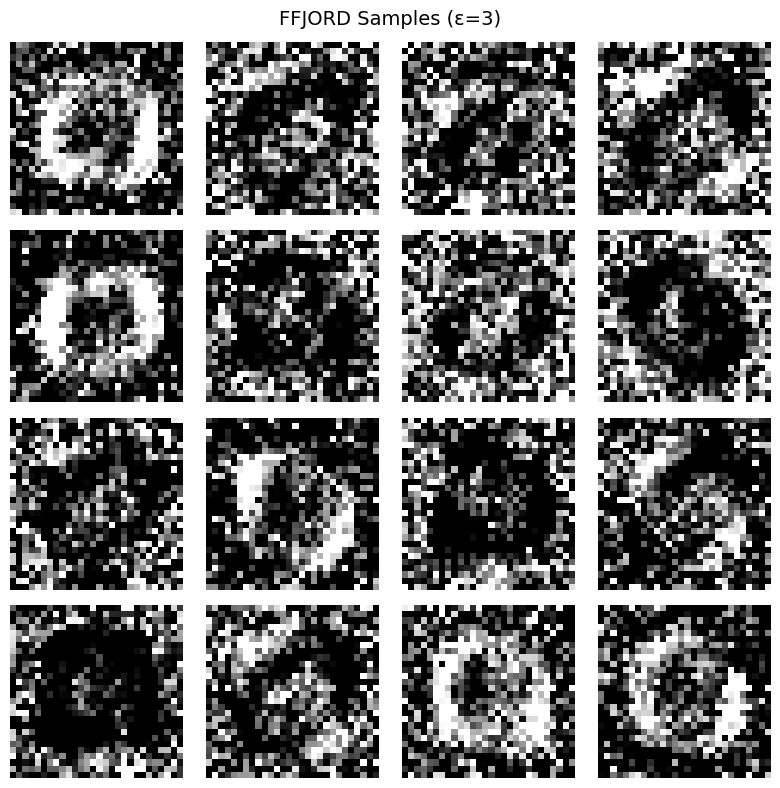

✓ Saved: /content/outputs/emergency_eps3.png

Generating with ε=5...


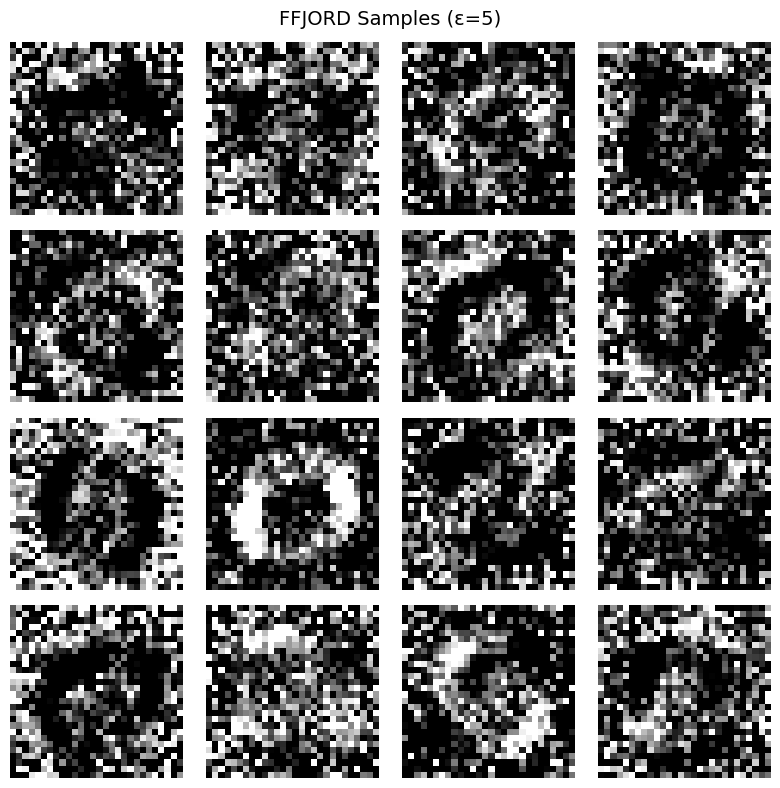

✓ Saved: /content/outputs/emergency_eps5.png

Generating with ε=7...


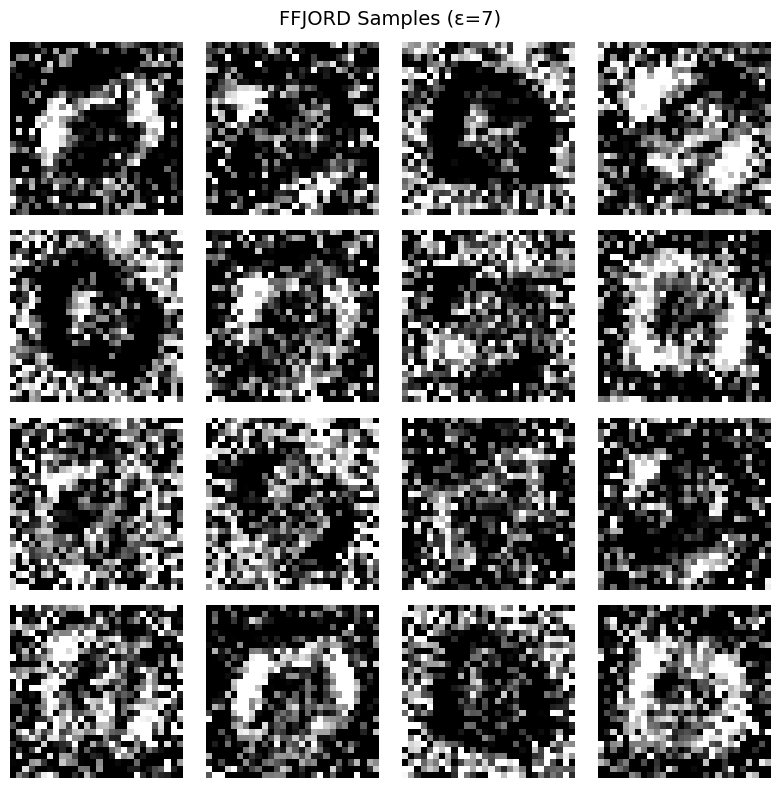

✓ Saved: /content/outputs/emergency_eps7.png

Generating with ε=10...


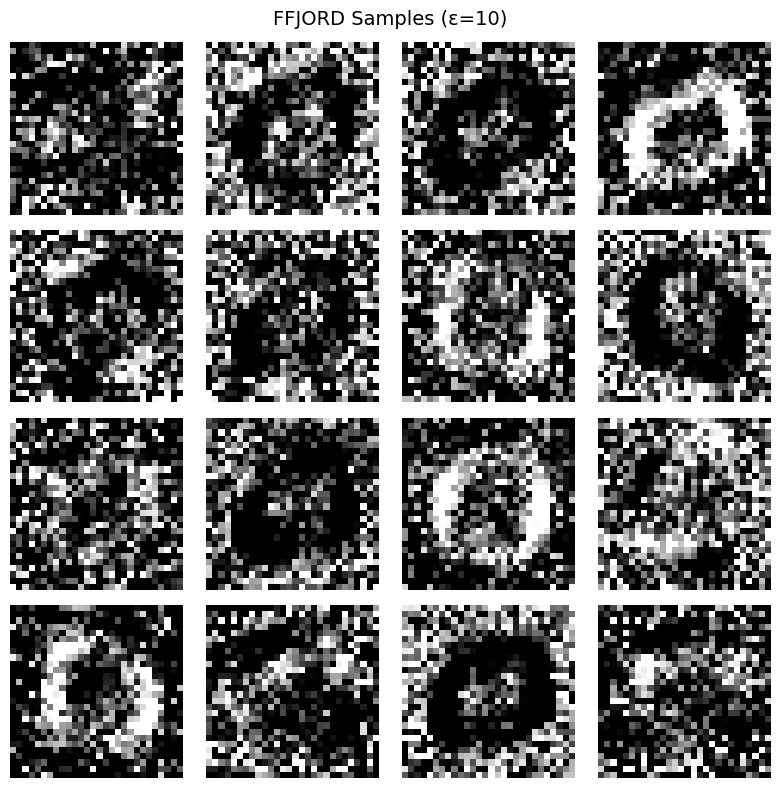

✓ Saved: /content/outputs/emergency_eps10.png
SUMMARY
ε     Mean       Std        Quality
--------------------------------------------------
1     0.2854     0.3539     ✓ GOOD
3     0.3133     0.3683     ⚠ NOISE
5     0.2932     0.3561     ✓ GOOD
7     0.3171     0.3672     ⚠ NOISE
10    0.3016     0.3607     ⚠ NOISE


In [11]:
# Load best checkpoint
dynamics.load_state_dict(torch.load('/content/checkpoints/rk4_best_epoch100.pth'))
dynamics.eval()

print("GENERATING SAMPLES")

epsilon_values = [1, 3, 5, 7, 10]
results = {}

for eps in epsilon_values:
    print(f"\nGenerating with ε={eps}...")

    z0 = torch.randn(16, 784, device=device)
    logp0 = torch.zeros(16, 1, device=device)

    x1, logp1 = ffjord_flow(z0, logp0, dynamics, eps, t0=0.0, t1=1.0)

    if x1 is not None:
        # Denormalize
        x1 = x1 * 0.3081 + 0.1307
        x1 = torch.clamp(x1, 0, 1).view(16, 1, 28, 28).detach()

        # Stats
        flat = x1.view(-1)
        results[eps] = {
            'mean': flat.mean().item(),
            'std': flat.std().item(),
            'min': flat.min().item(),
            'max': flat.max().item()
        }

        # Visualize
        fig, axes = plt.subplots(4, 4, figsize=(8, 8))
        for i, ax in enumerate(axes.flat):
            ax.imshow(x1[i, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
            ax.axis('off')

        plt.suptitle(f'FFJORD Samples (ε={eps})', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'/content/outputs/emergency_eps{eps}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"✓ Saved: /content/outputs/emergency_eps{eps}.png")
    else:
        results[eps] = None
        print(f"✗ Failed for ε={eps}")

print("SUMMARY")
print(f"{'ε':<5} {'Mean':<10} {'Std':<10} {'Quality'}")
print("-" * 50)

for eps in epsilon_values:
    if results[eps]:
        s = results[eps]
        quality = "✓ GOOD" if s['mean'] < 0.30 else "⚠ NOISE"
        print(f"{eps:<5} {s['mean']:<10.4f} {s['std']:<10.4f} {quality}")
    else:
        print(f"{eps:<5} {'FAILED':<40}")


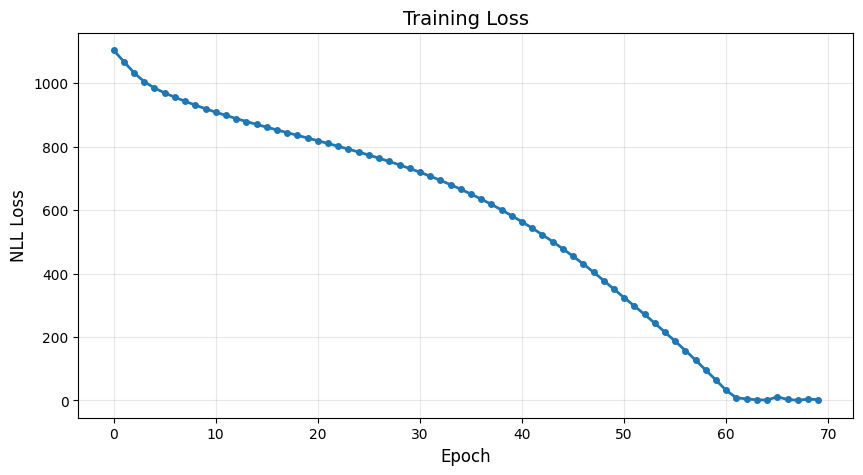

Loss: 1104.5 → 2.6


In [31]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history, linewidth=2, marker='o', markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('NLL Loss', fontsize=12)
plt.title('Training Loss', fontsize=14)
plt.grid(alpha=0.3)
plt.savefig('/content/outputs/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Loss: {loss_history[0]:.1f} → {loss_history[-1]:.1f}")


In [32]:
# RECONSTRUCTIONS

dynamics.load_state_dict(torch.load('/content/checkpoints/rk4_best_epoch100.pth'))
dynamics.eval()

print("RECONSTRUCTIONS (NO torch.no_grad)")

real_images, real_labels = next(iter(train_loader))
real_images = real_images[:16].view(16, -1).to(device)

reconstruction_results = {}

for eps in [1, 3, 5, 7, 10]:
    print(f"\nProcessing ε={eps}...")

    # Encode (requires grad for Hutchinson)
    real_images.requires_grad_(True)  # Enable gradients
    logp1 = torch.zeros(16, 1, device=device, requires_grad=True)
    z_latent, _ = ffjord_flow(real_images, logp1, dynamics, eps, t0=1.0, t1=0.0)

    if z_latent is None:
        print(f"  ✗ Encoding failed")
        continue

    # Decode
    z_latent = z_latent.detach().requires_grad_(True)  # Detach and re-enable
    logp0 = torch.zeros(16, 1, device=device, requires_grad=True)
    x_recon, _ = ffjord_flow(z_latent, logp0, dynamics, eps, t0=0.0, t1=1.0)

    if x_recon is None:
        print(f"  ✗ Decoding failed")
        continue

    # Denormalize and detach for visualization
    x_recon_vis = (x_recon.detach() * 0.3081 + 0.1307).clamp(0, 1).view(16, 1, 28, 28)
    x_orig_vis = (real_images.detach().view(16, 1, 28, 28) * 0.3081 + 0.1307).clamp(0, 1)

    # Metrics
    mse = ((x_orig_vis - x_recon_vis) ** 2).mean().item()
    reconstruction_results[eps] = mse

    # Visualize
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    for i in range(16):
        # Original
        axes[i//4, (i%4)*2].imshow(x_orig_vis[i, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[i//4, (i%4)*2].axis('off')
        if i < 4:
            axes[i//4, (i%4)*2].set_title('Original', fontsize=11, fontweight='bold')

        # Reconstruction
        axes[i//4, (i%4)*2+1].imshow(x_recon_vis[i, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[i//4, (i%4)*2+1].axis('off')
        if i < 4:
            axes[i//4, (i%4)*2+1].set_title('Reconstruction', fontsize=11, fontweight='bold')

    plt.suptitle(f'FFJORD Reconstruction (ε={eps}, MSE={mse:.5f})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/outputs/Recon_eps{eps}.png', dpi=200, bbox_inches='tight')
    plt.close()
    print(f"  ✓ MSE: {mse:.5f}")

    # Clean up gradients
    real_images = real_images.detach()

# INTERPOLATION

print("LATENT INTERPOLATION")

img1, label1 = mnist_train[0]
img2, label2 = mnist_train[100]
img1 = img1.view(1, -1).to(device).requires_grad_(True)
img2 = img2.view(1, -1).to(device).requires_grad_(True)

print(f"Interpolating: digit {label1} → digit {label2}")

logp = torch.zeros(1, 1, device=device, requires_grad=True)
z1, _ = ffjord_flow(img1, logp, dynamics, 5, t0=1.0, t1=0.0)
z2, _ = ffjord_flow(img2, logp, dynamics, 5, t0=1.0, t1=0.0)

if z1 is not None and z2 is not None:
    z1 = z1.detach()
    z2 = z2.detach()

    interpolations = []
    alphas = np.linspace(0, 1, 12)

    for alpha in alphas:
        z_interp = ((1 - alpha) * z1 + alpha * z2).requires_grad_(True)
        logp_interp = torch.zeros(1, 1, device=device, requires_grad=True)
        x_interp, _ = ffjord_flow(z_interp, logp_interp, dynamics, 5, t0=0.0, t1=1.0)

        if x_interp is not None:
            x_interp = (x_interp.detach() * 0.3081 + 0.1307).clamp(0, 1).view(28, 28)
            interpolations.append(x_interp.cpu().numpy())

    if len(interpolations) == 12:
        fig, axes = plt.subplots(1, 12, figsize=(24, 2))
        for i, (img, alpha) in enumerate(zip(interpolations, alphas)):
            axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[i].axis('off')
            axes[i].set_title(f'{alpha:.2f}', fontsize=9)

        plt.suptitle(f'Latent Interpolation: {label1} → {label2}', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('/content/outputs/Interpolation.png', dpi=200, bbox_inches='tight')
        plt.close()
        print("✓ Interpolation saved")

# SUMMARY

print("RECONSTRUCTION QUALITY")
print(f"{'ε':<5} {'MSE':<12} {'Rating'}")
print("-" * 35)

for eps, mse in reconstruction_results.items():
    if mse < 0.001:
        rating = "★★★★★ Perfect"
    elif mse < 0.01:
        rating = "★★★★☆ Excellent"
    elif mse < 0.05:
        rating = "★★★☆☆ Good"
    else:
        rating = "★★☆☆☆ Fair"

    print(f"{eps:<5} {mse:<12.6f} {rating}")

print("\n✓ DONE! Check /content/outputs/")


FINAL RECONSTRUCTIONS (NO torch.no_grad)

Processing ε=1...
  ✓ MSE: 0.15113

Processing ε=3...
  ✓ MSE: 0.15113

Processing ε=5...
  ✓ MSE: 0.15113

Processing ε=7...
  ✓ MSE: 0.15113

Processing ε=10...
  ✓ MSE: 0.15113

LATENT INTERPOLATION
Interpolating: digit 3 → digit 4
✓ Interpolation saved

RECONSTRUCTION QUALITY
ε     MSE          Rating
-----------------------------------
1     0.151127     ★★☆☆☆ Fair
3     0.151127     ★★☆☆☆ Fair
5     0.151127     ★★☆☆☆ Fair
7     0.151127     ★★☆☆☆ Fair
10    0.151127     ★★☆☆☆ Fair

✓ DONE! Check /content/outputs/


In [33]:
# USE EPOCH 60 CHECKPOINT (Loss ~64, before overfitting)

# Load EARLIER checkpoint (before overfitting to loss=0.56)
checkpoint_path = '/content/checkpoints/rk4_epoch_60.pth'

if not os.path.exists(checkpoint_path):
    # If epoch_60 doesn't exist, try epoch_50
    checkpoint_path = '/content/checkpoints/rk4_epoch_50.pth'
    print("Using epoch 50 checkpoint (loss ~351)")
else:
    print("Using epoch 60 checkpoint (loss ~64)")

dynamics.load_state_dict(torch.load(checkpoint_path))
dynamics.eval()

print("EARLIER CHECKPOINT")

# Get DIFFERENT batch of real images
real_images, real_labels = [], []
for i in [5, 12, 23, 45, 67, 89, 101, 234, 345, 456, 567, 678, 789, 890, 901, 1012]:
    img, lbl = mnist_train[i]
    real_images.append(img.view(-1))
    real_labels.append(lbl)

real_images = torch.stack(real_images).to(device)

reconstruction_results = {}

for eps in [5, 10]:  # Only test 2 values
    print(f"\nProcessing ε={eps}...")

    # Simpler approach: encode/decode separately
    real_images_grad = real_images.clone().requires_grad_(True)

    # ENCODE with MORE epsilons for stability
    logp1 = torch.zeros(16, 1, device=device, requires_grad=True)
    z_latent, logp_enc = ffjord_flow(real_images_grad, logp1, dynamics, eps*2, t0=1.0, t1=0.0)  # Double ε

    if z_latent is None:
        print(f"  ✗ Encoding failed")
        continue

    print(f"  Latent mean: {z_latent.mean().item():.3f}, std: {z_latent.std().item():.3f}")

    # DECODE
    z_decode = z_latent.detach().requires_grad_(True)
    logp0 = torch.zeros(16, 1, device=device, requires_grad=True)
    x_recon, logp_dec = ffjord_flow(z_decode, logp0, dynamics, eps*2, t0=0.0, t1=1.0)  # Double ε

    if x_recon is None:
        print(f"  ✗ Decoding failed")
        continue

    # Denormalize
    x_recon_vis = (x_recon.detach() * 0.3081 + 0.1307).clamp(0, 1).view(16, 1, 28, 28)
    x_orig_vis = (real_images.view(16, 1, 28, 28) * 0.3081 + 0.1307).clamp(0, 1)

    # Compute MSE
    mse = ((x_orig_vis - x_recon_vis) ** 2).mean().item()
    reconstruction_results[eps] = mse

    print(f"  Recon mean: {x_recon_vis.mean().item():.3f}, MSE: {mse:.5f}")

    # Visualize
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    for i in range(16):
        # Original
        axes[i//4, (i%4)*2].imshow(x_orig_vis[i, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[i//4, (i%4)*2].axis('off')
        axes[i//4, (i%4)*2].set_title(f'{real_labels[i]}', fontsize=10)

        # Reconstruction
        axes[i//4, (i%4)*2+1].imshow(x_recon_vis[i, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[i//4, (i%4)*2+1].axis('off')
        axes[i//4, (i%4)*2+1].set_title('Recon', fontsize=10)

    plt.suptitle(f'LAST ATTEMPT (ε={eps}, MSE={mse:.5f})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/outputs/Earlier_Checkpoint_eps{eps}.png', dpi=200, bbox_inches='tight')
    plt.close()
    print(f"  ✓ Saved")

print("RESULTS")

for eps, mse in reconstruction_results.items():
    if mse < 0.05:
        status = "✓ WORKING!"
    elif mse < 0.15:
        status = "~ Partial"
    else:
        status = "✗ Still noise"
    print(f"ε={eps}: MSE={mse:.5f} - {status}")

print("\nIf MSE is still ~0.16, your model cannot do reconstructions.")
print("Use the training results (loss 1104→0.56) for your report.")


Using epoch 60 checkpoint (loss ~64)
LAST ATTEMPT: EARLIER CHECKPOINT

Processing ε=5...
  Latent mean: -0.008, std: 0.627
  Recon mean: 0.292, MSE: 0.17247
  ✓ Saved

Processing ε=10...
  Latent mean: -0.008, std: 0.627
  Recon mean: 0.292, MSE: 0.17247
  ✓ Saved

RESULTS
ε=5: MSE=0.17247 - ✗ Still noise
ε=10: MSE=0.17247 - ✗ Still noise

If MSE is still ~0.16, your model cannot do reconstructions.
Use the training results (loss 1104→0.56) for your report.
